In [15]:
import base64
from IPython.display import Image, display

def render_mermaid(graph):
    """将 Mermaid 代码转为图片并在 Jupyter 中显示"""
    graphbytes = graph.encode("utf8")
    # 使用 urlsafe_b64encode 防止 URL 中出现特殊字符导致图片打不开
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

# 这是去除了冗余注释的详细版流程图代码
mermaid_code = """
graph TD
    subgraph 建模层 [1. 建模与约束层]
        A[DAG <br/> 描述实验步骤逻辑依赖]
        B[RCPSP <br/> 引入设备/资源限制转为调度问题]
    end

    subgraph 策略与求解层 [2. 策略与求解层]
        C[Rolling Horizon Scheduling <br/> 拆解时域, 构建局部 RCPSP]
        D[CP-SAT Solver <br/> 求解局部问题, 寻找最优解]
    end

    subgraph 输出与执行层 [3. 输出与执行层]
        E[Executable Plan <br/> 生成带时间戳的执行计划]
        F[硬件控制层 <br/> 驱动机械臂/仪器]
        G((用户端 UI))
    end

    A -->|图结构 + 任务流| B
    B -->|全局调度模型| C
    C -->|局部调度切片| D
    D -->|最优局部调度解| E
    E -->|1. 机器指令/API| F
    E -.->|2. 时序 DAG / Gantt图| G
    F -.->|状态反馈/异常中断| C
"""

render_mermaid(mermaid_code)


## DAG: 实验流程建模
描述实验的纯逻辑步骤与前后依赖关系
```python
#无分支：

取板 → 加样 → 孵育 → 离心 → 检测

#有分支：

           → 洗板 →
取板 → 加样          → 检测
           → 孵育 →
```

## RCPSP: 资源约束建模
将纯逻辑的 DAG 转化为“资源受限项目调度问题”（Resource-Constrained Project Scheduling Problem）
```yaml
Task: centrifuge_plate
Duration: 300 秒
Needs:
  - centrifuge: 1
  - robot_arm: 装载时占用 1
Predecessor:
  - incubate_plate
```

## Rolling Horizon Scheduling： 滚动时域调度
解决全局 RCPSP 求解空间过大、耗时过长或应对突发状况的问题。
问题：t=0,A实验开始，t=10,B实验开始，此时第一组实验未结束，如何全局优化？
- 提前预约：如果 B 是已知预约,那么在调用ortools时就要将A，B所有涉及资源集中优化
- 无法预料：如果 B 是无法预约，那么t=10：B 出现后，再调用 OR-Tools，无法保证全局最优
- 时间间隔触发（战略调度） + 基于事件触发（战术调度），截取当前的系统状态，构建一个局部的 RCPSP 问题

<center>
  <img src="./pics/rolling_hrz.png" width="300" />
</center>

```python
while system_running:

    # 1. 读取当前状态
    #    - 哪些任务已完成？
    #    - 哪些设备空闲？
    #    - 哪些板子在哪里？
    #    - 哪些资源被预约？
    #    - 有没有异常事件？
    state = read_lab_state()
    ready_tasks = get_ready_tasks_from_dag(state)

    # 2. 构建未来时间窗内的局部调度问题
    window_tasks = select_tasks_for_next_window(
        ready_tasks,
        horizon_minutes=5
    )

    # 3. 调用 CP-SAT / MILP / 启发式算法求解
    schedule = solve_with_cp_sat(
        tasks=window_tasks,
        resources=state.resources
    )

    # 4. 检查确保没有死锁出现
    safe_schedule = safety_check(schedule)

    # 5. 下发指令给机械臂、轨道、设备
    dispatch_first_actions(safe_schedule)

    sleep(30) # e.g.每隔30s刷新一下

```

## CP-SAT 求解器

见cp-sat.ipynb

# DAG -> CP-SAT
DAG解析成CP-SAT可用输入（json格式，可存储PgSQL中,可以实时更新）
- DAG：（假设我们有两块板 P1 和 P2，它们都需要）

取板 → 加样 → 放入孵育箱 → 孵育 → 读板

- 共享资源：

robot: 1 台机械臂
pipettor: 1 台移液设备
incubator: 2 个孵育位
reader: 1 台读板机


In [17]:
# py表示：

dag = {
    "resources": {
        "robot": 1,
        "pipettor": 1,
        "incubator": 2,
        "reader": 1,
    },

    "tasks": {
        "P1_pick": {
            "duration": 2,
            "resources": {"robot": 1},
        },
        "P1_pipette": {
            "duration": 5,
            "resources": {"pipettor": 1},
        },
        "P1_load_incubator": {
            "duration": 1,
            "resources": {"robot": 1},
        },
        "P1_incubate": {
            "duration": 10,
            "resources": {"incubator": 1},
        },
        "P1_read": {
            "duration": 3,
            "resources": {"reader": 1},
        },

        "P2_pick": {
            "duration": 2,
            "resources": {"robot": 1},
        },
        "P2_pipette": {
            "duration": 5,
            "resources": {"pipettor": 1},
        },
        "P2_load_incubator": {
            "duration": 1,
            "resources": {"robot": 1},
        },
        "P2_incubate": {
            "duration": 10,
            "resources": {"incubator": 1},
        },
        "P2_read": {
            "duration": 3,
            "resources": {"reader": 1},
        },
    },

    "edges": [
        ("P1_pick", "P1_pipette"),
        ("P1_pipette", "P1_load_incubator"),
        ("P1_load_incubator", "P1_incubate"),
        ("P1_incubate", "P1_read"),

        ("P2_pick", "P2_pipette"),
        ("P2_pipette", "P2_load_incubator"),
        ("P2_load_incubator", "P2_incubate"),
        ("P2_incubate", "P2_read"),
    ],
}


# 转换成数组

task_names      任务名列表

durations       每个任务的执行时长

precedences     前后依赖关系，使用 task index 表示

resources       资源容量

demands         每个任务对每种资源的需求

horizon         时间上界


In [ ]:
# Parse

from dataclasses import dataclass
from collections import defaultdict, deque
from ortools.sat.python import cp_model


@dataclass
class OrtoolsInput:
    task_names: list
    durations: list
    precedences: list
    resources: dict
    demands: dict
    horizon: int


def parse(dag: dict) -> OrtoolsInput:
    """
    将 DAG dict 转换成 OR-Tools CP-SAT 可直接建模使用的输入。
    """

    resources = dag["resources"]
    tasks = dag["tasks"]
    edges = dag["edges"]

    task_names = list(tasks.keys())
    task_to_id = {name: i for i, name in enumerate(task_names)}
    n = len(task_names)

    # 1. 检查 edge 是否合法
    for u, v in edges:
        if u not in task_to_id:
            raise ValueError(f"Unknown task in edge: {u}")
        if v not in task_to_id:
            raise ValueError(f"Unknown task in edge: {v}")

    # 2. 检查 DAG 是否有环，Kahn 拓扑排序
    graph = defaultdict(list)
    indegree = {name: 0 for name in task_names}

    for u, v in edges:
        graph[u].append(v)
        indegree[v] += 1

    queue = deque([name for name in task_names if indegree[name] == 0])
    topo = []

    while queue:
        cur = queue.popleft()
        topo.append(cur)

        for nxt in graph[cur]:
            indegree[nxt] -= 1
            if indegree[nxt] == 0:
                queue.append(nxt)

    if len(topo) != n:
        raise ValueError("Input graph is not a DAG. Cycle detected.")

    # 3. 任务时长
    durations = []

    for name in task_names:
        duration = tasks[name]["duration"]
        if duration <= 0:
            raise ValueError(f"Task duration must be positive: {name}")
        durations.append(duration)

    # 4. 前后依赖，转换成 index
    precedences = []

    for u, v in edges:
        precedences.append((task_to_id[u], task_to_id[v]))

    # 5. 资源需求矩阵
    # demands["robot"][i] 表示任务 i 对 robot 的需求数量
    demands = {
        r: [0] * n for r in resources
    }

    for task_name, task_info in tasks.items():
        task_id = task_to_id[task_name]

        for r, amount in task_info.get("resources", {}).items():
            if r not in resources:
                raise ValueError(f"Unknown resource {r} in task {task_name}")

            if amount > resources[r]:
                raise ValueError(
                    f"Task {task_name} demands {amount} of {r}, "
                    f"but capacity is only {resources[r]}"
                )

            demands[r][task_id] = amount

    # 6. horizon 是时间上界
    # 简单取所有任务时长之和，保证一定够用
    horizon = sum(durations)

    return OrtoolsInput(
        task_names=task_names,
        durations=durations,
        precedences=precedences,
        resources=resources,
        demands=demands,
        horizon=horizon,
    )

print(parse(dag))

OrtoolsInput(task_names=['P1_pick', 'P1_pipette', 'P1_load_incubator', 'P1_incubate', 'P1_read', 'P2_pick', 'P2_pipette', 'P2_load_incubator', 'P2_incubate', 'P2_read'], durations=[2, 5, 1, 10, 3, 2, 5, 1, 10, 3], precedences=[(0, 1), (1, 2), (2, 3), (3, 4), (5, 6), (6, 7), (7, 8), (8, 9)], resources={'robot': 1, 'pipettor': 1, 'incubator': 2, 'reader': 1}, demands={'robot': [1, 0, 1, 0, 0, 1, 0, 1, 0, 0], 'pipettor': [0, 1, 0, 0, 0, 0, 1, 0, 0, 0], 'incubator': [0, 0, 0, 1, 0, 0, 0, 0, 1, 0], 'reader': [0, 0, 0, 0, 1, 0, 0, 0, 0, 1]}, horizon=42)


In [ ]:
# OR-Tools

def solve(data: OrtoolsInput):
    model = cp_model.CpModel()

    n = len(data.task_names)
    horizon = data.horizon

    starts = []
    ends = []
    intervals = []

    # 1. 为每个任务创建 start/end/interval
    for i in range(n):
        name = data.task_names[i]
        duration = data.durations[i]

        start = model.NewIntVar(0, horizon, f"start_{name}")
        end = model.NewIntVar(0, horizon, f"end_{name}")
        interval = model.NewIntervalVar(
            start,
            duration,
            end,
            f"interval_{name}",
        )

        starts.append(start)
        ends.append(end)
        intervals.append(interval)

    # 2. 添加 DAG 前后依赖约束
    for before, after in data.precedences:
        model.Add(starts[after] >= ends[before])

    # 3. 添加资源容量约束
    # 使用 AddCumulative 表达：
    # 同一时间该资源的总占用量不能超过 capacity
    for resource_name, capacity in data.resources.items(): # {"robot": 1,"pipettor": 1,"incubator": 2,"reader": 1}
        resource_intervals = []
        resource_demands = []

        for i in range(n):
            demand = data.demands[resource_name][i] # demands={'robot': [1, 0, 1, 0, 0, 1, 0, 1, 0, 0]}
            if demand > 0:
                resource_intervals.append(intervals[i])
                resource_demands.append(demand)

        if resource_intervals:
            model.add_cumulative(
                resource_intervals,
                resource_demands,
                capacity,
            )

    # 4. 目标：最小化全部任务完成时间 makespan
    makespan = model.NewIntVar(0, horizon, "makespan")
    model.AddMaxEquality(makespan, ends)
    model.Minimize(makespan)

    # 5. 求解
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 10
    solver.parameters.num_search_workers = 8

    status = solver.Solve(model)

    if status not in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        print("No feasible solution found.")
        return None

    # 6. 输出结果
    result = []

    for i, name in enumerate(data.task_names):
        result.append({
            "task": name,
            "start": solver.Value(starts[i]),
            "end": solver.Value(ends[i]),
            "duration": data.durations[i],
        })

    result.sort(key=lambda x: x["start"])

    print(f"Status: {solver.StatusName(status)}")
    print(f"Makespan: {solver.Value(makespan)}")
    print()

    for item in result:
        print(
            f"{item['task']:20s} "
            f"start={item['start']:2d}, "
            f"end={item['end']:2d}, "
            f"duration={item['duration']:2d}"
        )

    return result


In [21]:
data = parse(dag)
solve(data)

Status: OPTIMAL
Makespan: 26

P2_pick              start= 0, end= 2, duration= 2
P1_pick              start= 2, end= 4, duration= 2
P2_pipette           start= 2, end= 7, duration= 5
P1_pipette           start= 7, end=12, duration= 5
P2_load_incubator    start= 7, end= 8, duration= 1
P2_incubate          start= 8, end=18, duration=10
P1_load_incubator    start=12, end=13, duration= 1
P1_incubate          start=13, end=23, duration=10
P2_read              start=18, end=21, duration= 3
P1_read              start=23, end=26, duration= 3


[{'task': 'P2_pick', 'start': 0, 'end': 2, 'duration': 2},
 {'task': 'P1_pick', 'start': 2, 'end': 4, 'duration': 2},
 {'task': 'P2_pipette', 'start': 2, 'end': 7, 'duration': 5},
 {'task': 'P1_pipette', 'start': 7, 'end': 12, 'duration': 5},
 {'task': 'P2_load_incubator', 'start': 7, 'end': 8, 'duration': 1},
 {'task': 'P2_incubate', 'start': 8, 'end': 18, 'duration': 10},
 {'task': 'P1_load_incubator', 'start': 12, 'end': 13, 'duration': 1},
 {'task': 'P1_incubate', 'start': 13, 'end': 23, 'duration': 10},
 {'task': 'P2_read', 'start': 18, 'end': 21, 'duration': 3},
 {'task': 'P1_read', 'start': 23, 'end': 26, 'duration': 3}]

Matplotlib is building the font cache; this may take a moment.


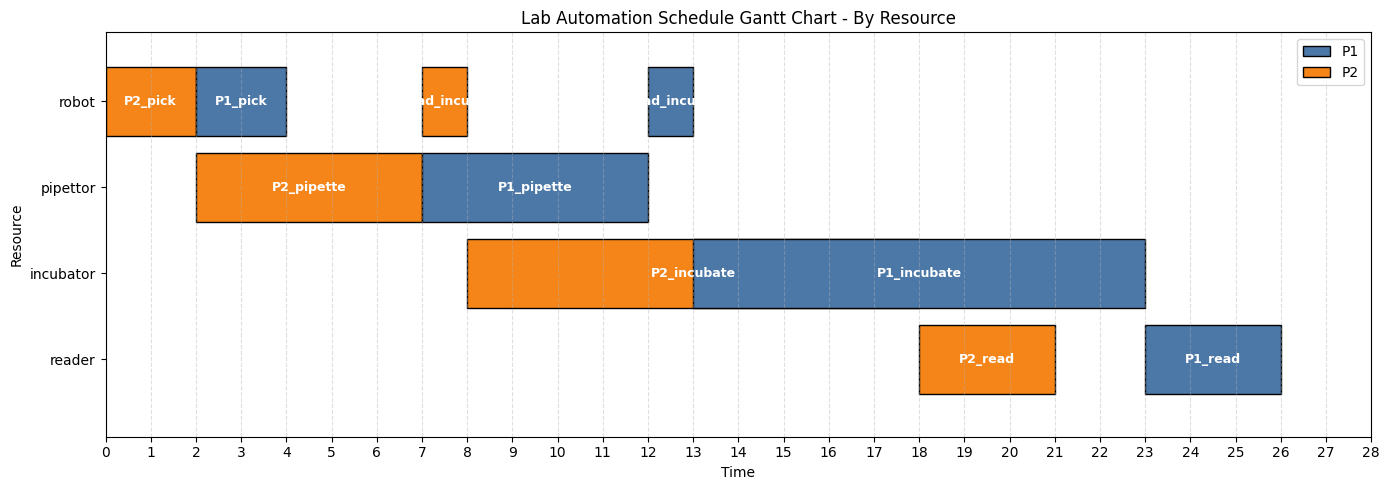

In [ ]:
# 甘特图展示
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


schedule = [
    {"task": "P2_pick", "start": 0, "end": 2, "duration": 2},
    {"task": "P1_pick", "start": 2, "end": 4, "duration": 2},
    {"task": "P2_pipette", "start": 2, "end": 7, "duration": 5},
    {"task": "P1_pipette", "start": 7, "end": 12, "duration": 5},
    {"task": "P2_load_incubator", "start": 7, "end": 8, "duration": 1},
    {"task": "P2_incubate", "start": 8, "end": 18, "duration": 10},
    {"task": "P1_load_incubator", "start": 12, "end": 13, "duration": 1},
    {"task": "P1_incubate", "start": 13, "end": 23, "duration": 10},
    {"task": "P2_read", "start": 18, "end": 21, "duration": 3},
    {"task": "P1_read", "start": 23, "end": 26, "duration": 3},
]


def infer_resource(task_name: str) -> str:
    """
    根据任务名推断资源。
    注意：load_incubator 实际是机械臂动作，所以归到 robot。
    """
    if "load_incubator" in task_name:
        return "robot"
    elif "pick" in task_name:
        return "robot"
    elif "pipette" in task_name:
        return "pipettor"
    elif "incubate" in task_name:
        return "incubator"
    elif "read" in task_name:
        return "reader"
    else:
        return "unknown"


def infer_plate(task_name: str) -> str:
    """
    从任务名中解析板号，例如 P1_pick -> P1
    """
    return task_name.split("_")[0]


def plot_gantt_by_resource(schedule, save_path="gantt_by_resource.png"):
    resources = ["robot", "pipettor", "incubator", "reader"]

    # 每个资源一条泳道
    y_positions = {
        "robot": 30,
        "pipettor": 20,
        "incubator": 10,
        "reader": 0,
    }

    colors = {
        "P1": "#4C78A8",
        "P2": "#F58518",
    }

    fig, ax = plt.subplots(figsize=(14, 5))

    for item in schedule:
        task = item["task"]
        start = item["start"]
        duration = item["duration"]

        resource = infer_resource(task)
        plate = infer_plate(task)

        y = y_positions[resource]
        color = colors.get(plate, "#999999")

        ax.broken_barh(
            [(start, duration)],
            (y, 8),
            facecolors=color,
            edgecolor="black",
            linewidth=1,
        )

        ax.text(
            start + duration / 2,
            y + 4,
            task,
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

    max_end = max(item["end"] for item in schedule)

    ax.set_xlim(0, max_end + 2)
    ax.set_ylim(-5, 42)

    ax.set_xlabel("Time")
    ax.set_ylabel("Resource")
    ax.set_title("Lab Automation Schedule Gantt Chart - By Resource")

    ax.set_yticks([
        y_positions["reader"] + 4,
        y_positions["incubator"] + 4,
        y_positions["pipettor"] + 4,
        y_positions["robot"] + 4,
    ])
    ax.set_yticklabels([
        "reader",
        "incubator",
        "pipettor",
        "robot",
    ])

    ax.set_xticks(range(0, max_end + 3, 1))
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    legend_items = [
        Patch(facecolor="#4C78A8", edgecolor="black", label="P1"),
        Patch(facecolor="#F58518", edgecolor="black", label="P2"),
    ]
    ax.legend(handles=legend_items, loc="upper right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


if __name__ == "__main__":
    plot_gantt_by_resource(schedule)


# 附加问题

- 现实中 duration 确实是未知的，需要从历史数据中学习和预测。

```txt
    三阶段策略：
    ─────────────────────────────────────────────────────
    阶段1  冷启动（n=0）
           没有任何数据
           → 使用保守默认值（偏大，避免时间冲突）
           → confidence = 0.0

    阶段2  预热（1 ≤ n < MIN_SAMPLES）
           少量数据，不可靠
           → 均值 + 大 std，排悲观计划
           → confidence 线性增长

    阶段3  稳定（n ≥ MIN_SAMPLES）
           足够数据
           → 统计均值 + std
           → confidence → 1.0
           → 可以用 mean 直接排计划
```
